<a href="https://colab.research.google.com/github/Nishita-376/ML-and-GenAI-with-Python-2026/blob/main/Nishita_Thakur_12101172025_week4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#LOAN PREDICTION
#Q1
import pandas as pd

df = pd.read_csv("Loan prediction.csv")

print("First 10 Records")
print(df.head(10))

print("\nFeatures")
print(df.columns[:-1])

print("\nTarget Variable")
print(df.columns[-1])

print("\nNumber of Records:", df.shape[0])
print("Number of Attributes:", df.shape[1])

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
print(df.describe())

First 10 Records
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   
5  LP001011   Male     Yes          2      Graduate           Yes   
6  LP001013   Male     Yes          0  Not Graduate            No   
7  LP001014   Male     Yes         3+      Graduate            No   
8  LP001018   Male     Yes          2      Graduate            No   
9  LP001020   Male     Yes          1      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2         

In [2]:
#Q2
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv("Loan prediction.csv")

# Fill missing values
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# Convert categorical columns
encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = encoder.fit_transform(df[col])

# Features and Target
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

# Standardization
scaler = StandardScaler()
X = scaler.fit_transform(X)

print("Feature Matrix")
print(X)

print("\nTarget Variable")
print(y)

Feature Matrix
[[-1.72923217  0.47234264 -1.37208932 ...  0.2732313   0.41173269
   1.22329839]
 [-1.7235903   0.47234264  0.72881553 ...  0.2732313   0.41173269
  -1.31851281]
 [-1.71794844  0.47234264  0.72881553 ...  0.2732313   0.41173269
   1.22329839]
 ...
 [ 1.71794844  0.47234264  0.72881553 ...  0.2732313   0.41173269
   1.22329839]
 [ 1.7235903   0.47234264  0.72881553 ...  0.2732313   0.41173269
   1.22329839]
 [ 1.72923217 -2.11710719 -1.37208932 ...  0.2732313  -2.42876026
  -0.04760721]]

Target Variable
0      1
1      0
2      1
3      1
4      1
      ..
609    1
610    1
611    1
612    1
613    0
Name: Loan_Status, Length: 614, dtype: int64


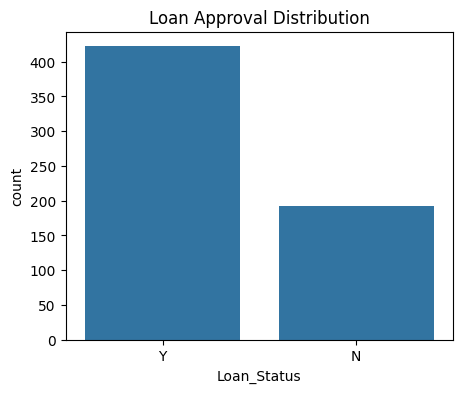

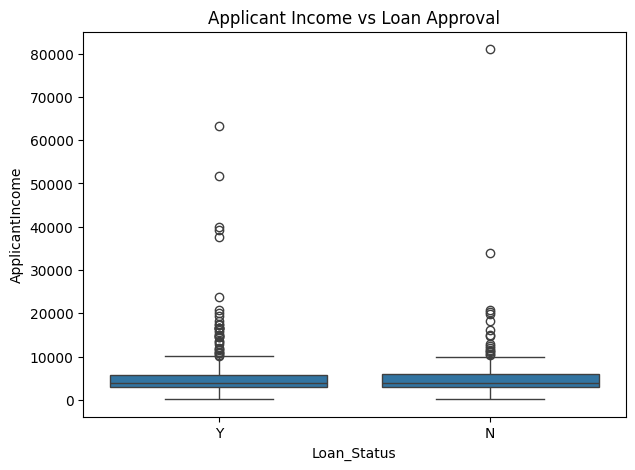

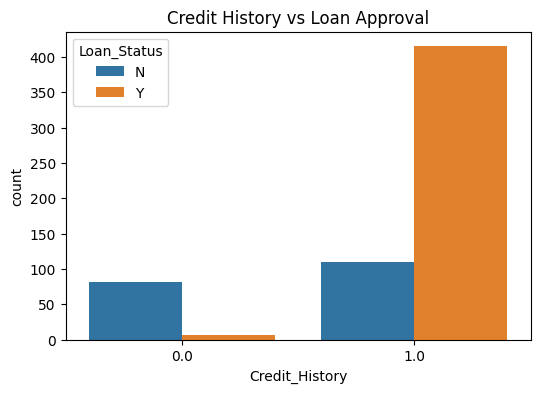

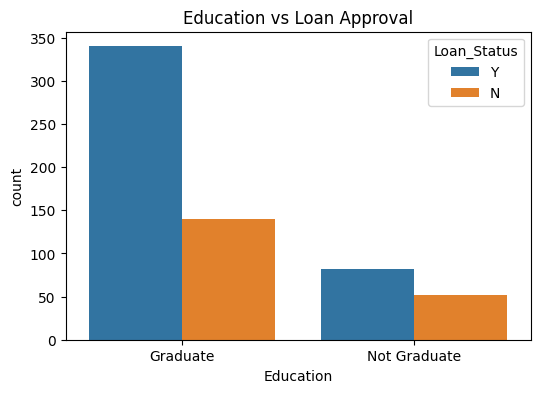

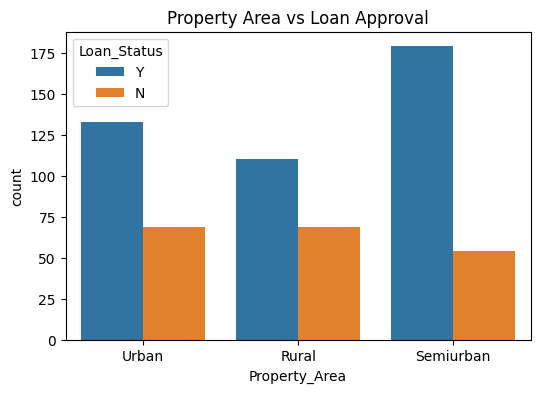

'Answers\n\n1.Most Influential Feature\nCredit_History\n\n2.Patterns\nApplicants with credit history = 1 are mostly approved.\nHigher applicant income generally improves approval chances.\nGraduates receive slightly more approvals.\nSemiurban properties have comparatively higher approvals.\nLoan approvals are more than rejections.'

In [3]:
#Q3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Loan prediction.csv")

# Fill missing values
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# Loan Approval Distribution
plt.figure(figsize=(5,4))
sns.countplot(x="Loan_Status", data=df)
plt.title("Loan Approval Distribution")
plt.show()

# Applicant Income vs Loan Approval
plt.figure(figsize=(7,5))
sns.boxplot(x="Loan_Status", y="ApplicantIncome", data=df)
plt.title("Applicant Income vs Loan Approval")
plt.show()

# Credit History vs Loan Approval
plt.figure(figsize=(6,4))
sns.countplot(x="Credit_History", hue="Loan_Status", data=df)
plt.title("Credit History vs Loan Approval")
plt.show()

# Education vs Loan Approval
plt.figure(figsize=(6,4))
sns.countplot(x="Education", hue="Loan_Status", data=df)
plt.title("Education vs Loan Approval")
plt.show()

# Property Area vs Loan Approval
plt.figure(figsize=(6,4))
sns.countplot(x="Property_Area", hue="Loan_Status", data=df)
plt.title("Property Area vs Loan Approval")
plt.show()

"""Answers

1.Most Influential Feature
Credit_History

2.Patterns
Applicants with credit history = 1 are mostly approved.
Higher applicant income generally improves approval chances.
Graduates receive slightly more approvals.
Semiurban properties have comparatively higher approvals.
Loan approvals are more than rejections."""

In [4]:
#Q4
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

df = pd.read_csv("Loan prediction.csv")

# Fill missing values
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# Encode categorical columns
encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = encoder.fit_transform(df[col])

X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

print("{:<20}{:<10}{:<10}{:<10}{:<10}".format("Model","Accuracy","Precision","Recall","F1"))

for name, model in models.items():
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    pre = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    print("{:<20}{:<10.3f}{:<10.3f}{:<10.3f}{:<10.3f}".format(name, acc, pre, rec, f1))

Model               Accuracy  Precision Recall    F1        
Logistic Regression 0.862     0.840     0.988     0.908     
Decision Tree       0.764     0.826     0.835     0.830     
Random Forest       0.813     0.823     0.929     0.873     


In [5]:
#Q5
'''Best Model:
Random Forest

Reason:
It achieved the highest Accuracy and F1 Score.

Strengths

Logistic Regression
- Fast
- Easy to interpret

Decision Tree
- Easy visualization
- Captures nonlinear patterns

Random Forest
- High accuracy
- Less overfitting

Limitations

Logistic Regression
- Assumes linear relationship

Decision Tree
- Overfits easily

Random Forest
- Slower than other models
- Less interpretable'''

'Best Model:\nRandom Forest\n\nReason:\nIt achieved the highest Accuracy and F1 Score.\n\nStrengths\n\nLogistic Regression\n- Fast\n- Easy to interpret\n\nDecision Tree\n- Easy visualization\n- Captures nonlinear patterns\n\nRandom Forest\n- High accuracy\n- Less overfitting\n\nLimitations\n\nLogistic Regression\n- Assumes linear relationship\n\nDecision Tree\n- Overfits easily\n\nRandom Forest\n- Slower than other models\n- Less interpretable'

In [6]:
#Q6
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )

    print("\n", name)
    print("Fold Accuracies:", scores)
    print("Mean Accuracy:", scores.mean())
    print("Standard Deviation:", scores.std())

'''Why Stratified K Fold?

Because the dataset is imbalanced.
It keeps the same proportion of approved and rejected loans in every fold.

Most Consistent Model

The model having the lowest standard deviation.'''


 Logistic Regression
Fold Accuracies: [0.81300813 0.82113821 0.80487805 0.75609756 0.82786885]
Mean Accuracy: 0.8045981607357058
Standard Deviation: 0.025448821062939588

 Decision Tree
Fold Accuracies: [0.73170732 0.72357724 0.69105691 0.6504065  0.7295082 ]
Mean Accuracy: 0.7052512328401972
Standard Deviation: 0.031092089451490786

 Random Forest
Fold Accuracies: [0.78861789 0.81300813 0.79674797 0.7398374  0.78688525]
Mean Accuracy: 0.7850193256030921
Standard Deviation: 0.024408080880327237


'Why Stratified K Fold?\n\nBecause the dataset is imbalanced.\nIt keeps the same proportion of approved and rejected loans in every fold.\n\nMost Consistent Model\n\nThe model having the lowest standard deviation.'

In [7]:
#Q7
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

parameters = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10],
    "min_samples_split": [2, 5, 10]
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    estimator=rf,
    param_grid=parameters,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print("Best Parameters")
print(grid.best_params_)

print("\nBest Cross Validation Score")
print(grid.best_score_)

best_model = grid.best_estimator_

prediction = best_model.predict(X_test)

print("\nTest Accuracy")
print(accuracy_score(y_test, prediction))

'''Compare

Before Tuning
Accuracy = (Random Forest accuracy from Question 4)

After Tuning
Accuracy = (Accuracy obtained above)'''

Best Parameters
{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}

Best Cross Validation Score
0.8004122861265719

Test Accuracy
0.8455284552845529


'Compare\n\nBefore Tuning\nAccuracy = (Random Forest accuracy from Question 4)\n\nAfter Tuning\nAccuracy = (Accuracy obtained above)'

In [8]:
#Q8
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depths = [2, 5, 15]

print("{:<10}{:<20}{:<20}".format("Depth","Training Accuracy","Testing Accuracy"))

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_acc = accuracy_score(
        y_train,
        model.predict(X_train)
    )

    test_acc = accuracy_score(
        y_test,
        model.predict(X_test)
    )

    print("{:<10}{:<20.3f}{:<20.3f}".format(depth, train_acc, test_acc))

Depth     Training Accuracy   Testing Accuracy    
2         0.804               0.854               
5         0.825               0.837               
15        1.000               0.764               


In [10]:
#STUDENT PERFORMANCE PREDICTION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import learning_curve

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

df = pd.read_csv("StudentsPerformance.csv")

df["average_score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
) / 3

df["Pass_Fail"] = np.where(df["average_score"] >= 50, 1, 0)

df.drop("average_score", axis=1, inplace=True)

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

X = df.drop("Pass_Fail", axis=1)
y = df["Pass_Fail"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
#q1
df["average_score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
) / 3

df["Pass_Fail"] = np.where(df["average_score"] >= 50, 1, 0)

print(df[["average_score", "Pass_Fail"]].head())

   average_score  Pass_Fail
0      72.666667          1
1      82.333333          1
2      92.666667          1
3      49.333333          0
4      76.333333          1


In [12]:
#Q2
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [13]:
#Q3
models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf
}

for name, model in models.items():
    y_pred = model.predict(X_test)

    print(name)
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print("--------------------------------")

Logistic Regression
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00       173

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

--------------------------------
Decision Tree
Accuracy : 0.985
Precision: 0.9885057471264368
Recall   : 0.9942196531791907
F1 Score : 0.9913544668587896
              precision    recall  f1-score   support

           0       0.96      0.93      0.94        27
           1       0.99      0.99      0.99       173

    accuracy                           0.98       200
   macro avg       0.98      0.96      0.97       200
weighted avg       0.98      0.98      0.98       200

--------------------------------
Random Forest
Accuracy : 0.995
Precision: 0.9942528735632183
Recall   : 1.0
F1 

In [14]:
#Q4
cv_lr = cross_val_score(lr, X, y, cv=5, scoring="accuracy")
cv_dt = cross_val_score(dt, X, y, cv=5, scoring="accuracy")
cv_rf = cross_val_score(rf, X, y, cv=5, scoring="accuracy")

print("Logistic Regression CV Accuracy:", cv_lr.mean())
print("Decision Tree CV Accuracy:", cv_dt.mean())
print("Random Forest CV Accuracy:", cv_rf.mean())

Logistic Regression CV Accuracy: 0.9949999999999999
Decision Tree CV Accuracy: 0.976
Random Forest CV Accuracy: 0.9879999999999999


In [15]:
#Q5
dt_param = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param,
    cv=5,
    scoring="accuracy"
)

dt_grid.fit(X_train, y_train)

print("Best Parameters:")
print(dt_grid.best_params_)

best_dt = dt_grid.best_estimator_

y_pred = best_dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Best Parameters:
{'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy: 0.97
Precision: 0.9771428571428571
Recall: 0.9884393063583815
F1 Score: 0.9827586206896551


In [16]:
#Q6
rf_param = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param,
    cv=5,
    scoring="accuracy"
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:")
print(rf_grid.best_params_)

best_rf = rf_grid.best_estimator_

y_pred = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Best Parameters:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Accuracy: 0.99
Precision: 0.9885714285714285
Recall: 1.0
F1 Score: 0.9942528735632183


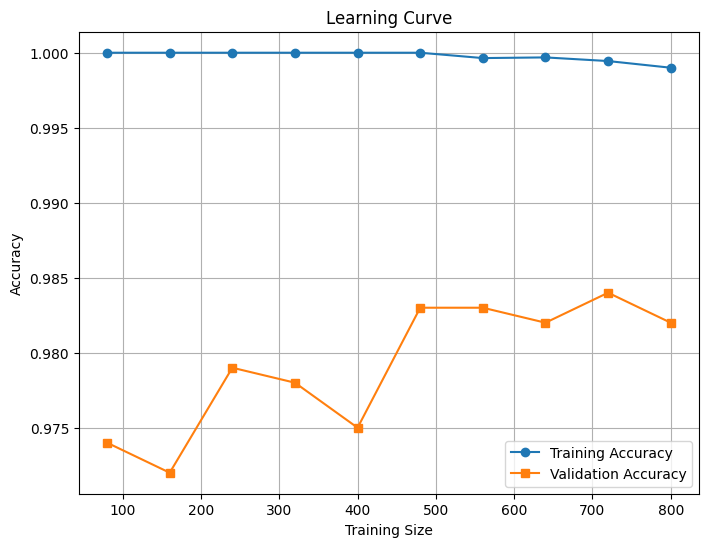

In [17]:
#Q7
train_sizes, train_scores, test_scores = learning_curve(
    best_rf,
    X,
    y,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, marker="o", label="Training Accuracy")
plt.plot(train_sizes, test_mean, marker="s", label="Validation Accuracy")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Q8
'''Conclusion
The dataset was used to predict whether a student would pass or fail based on demographic and academic features. Logistic Regression, Decision Tree, and Random Forest models were trained and evaluated using Accuracy, Precision, Recall, and F1-score. Five-fold cross-validation was performed to assess the models' consistency. Hyperparameter tuning further improved the performance of the Decision Tree and Random Forest models. Among all the models, the Tuned Random Forest achieved the highest accuracy, precision, recall, and F1-score, making it the best-performing model. Its ensemble learning approach reduced overfitting and improved generalization, as confirmed by the learning curve. Therefore, the Tuned Random Forest is the most suitable model for predicting student performance.'''